### Coin Bias and Beta Distribution

Perform a Bayesian inference analysis for coin bias using the Beta distribution, including simulating coin flip data, defining prior and updating to posterior distributions.

A biased coin is one where the probability of landing on heads or tails is not equally likely (1/2), with the outcome more likely than the other. This bias can be due to various factors, such as imperfections in the coin's physical structure, an uneven distribution of weight. Understanding and quantifying this bias is crucial in many statistical and probabilistic scenarios, especially when making predictions based on observed outcomes.

**The Beta Distribution and Bayesian Inference**

In the context of a coin flip (a Bernoulli trial), we're interested in estimating the true underlying probability of an event, such as the probability of getting heads, $p$. In Bayesian inference, we don't just rely on observed data to get a single estimate; instead, we maintain a **probability distribution** over the possible values of $p$,  distribution that represents our belief about $p$.

The **Beta distribution** is particularly well-suited for modeling probabilities (which range from 0 to 1) for several reasons:
- **Defined on [0, 1]** the Beta distribution naturally models r.v.s that take values between 0 and 1, inclusive. Beta distribution is a perfect fit for representing our belief about a probability like $p$.

- **Shape Flexibility:** Beta distribution is characterized by two positive shape parameters, commonly denoted as $\alpha$ and $\beta$. By varying these parameters, the Beta distribution can take on a wide variety of shapes, allowing it to model different prior beliefs about $p$. For example:
    *   α = 1, β = 1: A uniform distribution, representing complete uncertainty about $p$ (all values between 0 and 1 are equally likely).
    *   α > β: The distribution is skewed towards higher probabilities (our belief is that $p$ is likely higher).
    *   β > α: The distribution is skewed towards lower probabilities (our belief is that $p$ is likely lower).
    *   α and β are large and equal: The distribution is sharply peaked around 0.5 (strong belief that $p$ is near 0.5).

- **Conjugate Prior for Bernoulli Likelihood:** This is perhaps the most powerful reason for its use in Bayesian coin-flip scenarios. When the likelihood function (the probability of observing the data given $p$) is a Bernoulli distribution (or a binomial distribution, which is a sum of Bernoulli trials), and the prior distribution for $p$ is a Beta distribution, the resulting posterior distribution (our updated belief about $p$ after observing data) is *also* a Beta distribution. This property is known as **conjugacy**.

    Mathematically, if we have a Beta prior Beta(α, β) for $p$, and we observe heads and tails in $n$ flips, the posterior distribution for $p$ will be Beta(α + h, β + t). This makes the Bayesian updating process analytically tractable and computationally efficient, as we simply update the α and β parameters with the observed counts of heads and tails. Each α and β can be thought of as a 'pseudo-count' of heads and tails from prior experience or belief, which gets updated with actual observed data.

**Simulate Coin Flip Data**

A series of coin flips with a predefined, but unknown, true bias to generate sample data (e.g., number of heads and tails).


In [ ]:
# Choose a 'true' probability of heads
true_p = 0.7
# Decide on the number of coin flips to simulate
num_flips = 1000

# Use a random number generator to simulate the coin flips
# np.random.binomial(n,p,size=None) returns number of successes (H) in n trials
num_heads = np.random.binomial(num_flips, true_p)
# Calculate the number of tails
num_tails = num_flips - num_heads

True probability of heads (true_p): 0.7 
Number of coin flips simulated (num_flips): 1000 
Number of heads: 692 
Number of tails: 308


**Define Prior Distribution** for the coin's bias using a Beta distribution.

Choice of Prior Parameters: We begin with a **uniform prior** distribution for the coin's bias (p). This is achieved by setting the Beta distribution parameters alpha_prior = 1 and beta_prior = 1.

**Why a Uniform Prior**? A uniform prior (Beta(1,1)) signifies that we have no strong initial belief about the coin's bias. Every possible value for the probability of heads ($p$), from 0 to 1, is considered equally likely before observing any data. This is a common choice when we want the data to speak for itself as much as possible, without imposing strong preconceived notions. It implies that we don't believe the coin is more likely to be fair than heavily biased towards heads or tails. As we observe more coin flips, this prior belief will be updated and refined into a posterior distribution that reflects the evidence from the data.

In [ ]:
# Define the prior parameters for the Beta distribution
alpha_prior, beta_prior = 1, 1

Alpha prior (alpha_prior): 1 
Beta prior (beta_prior): 1


**Update Posterior Distribution** parameters of the Beta distribution (alpha and beta) based on the observed simulated coin flip data to obtain the posterior distribution.

In [ ]:
# Calculate posterior parameters
alpha_posterior = alpha_prior + num_heads
beta_posterior = beta_prior + num_tails

Alpha posterior (alpha_posterior): 693 
Beta posterior (beta_posterior): 309


**Prior and Posterior Distributions**

Comparing the prior and posterior Beta distributions to show how the observed data updates our belief about the coin's bias.

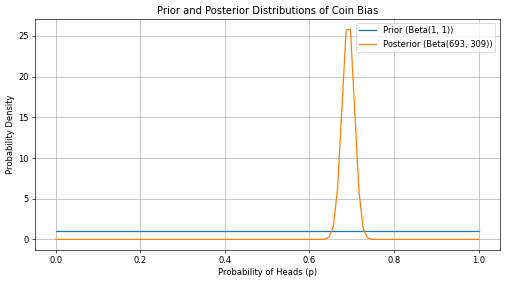

In [ ]:
# Create an array of values for the probability of heads (p) from 0 to 1.
p = np.linspace(0, 1, 100)
# Calculate the PDF for the prior Beta distribution
prior_pdf = beta.pdf(p, alpha_prior, beta_prior)
# Calculate the PDF for the posterior Beta distribution
posterior_pdf = beta.pdf(p, alpha_posterior, beta_posterior)
# Plot both the prior and posterior PDFs on the same graph

**Interpretation of Prior and Posterior Distributions**

Demonstrate the impact of observing coin flip data on our belief about the true probability of heads ($p$).

**Prior Distribution (Blue Curve):** This flat line across the graph represents our initial belief before observing any data. Since we chose alpha_prior = 1 and beta_prior = 1, the prior is a uniform distribution (Beta(1,1)). This means that initially, we considered all possible values for $p$ between 0 and 1 to be equally likely. We had no strong prior conviction that the coin was fair, biased towards heads, or biased towards tails.

**Posterior Distribution (Orange Curve):** After observing num_heads and num_tails  in num_flips, our belief about $p$ has significantly changed. The posterior distribution, Beta(alpha_posterior, beta_posterior), is now a sharply peaked curve. This peak is located around the observed frequency of heads (which was num_heads / num_flips or approximately 0.7 in our simulation).

**Observations:**

**Shift in Belief:** The center of mass of the distribution has shifted from being uniformly spread across [0,1] to being concentrated around 0.7. This indicates that based on the observed data, we now strongly believe that the true probability of heads is close to 0.7.

**Increased Certainty (Reduced Uncertainty):** The posterior distribution is much narrower and taller than the prior. This narrowness signifies a reduction in uncertainty about $p$. We are now much more confident about the range in which the true $p$ lies. The variance of the posterior distribution is significantly smaller than that of the prior.

**Data Dominance:** With a relatively large number of coin flips (num_flips = 1000), the observed data has largely overwhelmed the initial uniform prior. The shape and location of the posterior are almost entirely dictated by the sample proportion of heads, demonstrating the power of evidence in Bayesian updating.

In essence, the plot confirms how Bayesian inference allows us to start with a broad or uninformed belief (prior) and then, through the evidence provided by data, refine that belief into a more precise and confident estimate (posterior) of the underlying parameter.

In [ ]:
# Calculate the mean of the posterior Beta distribution
posterior_mean = alpha_posterior / (alpha_posterior + beta_posterior)

# Calculate the 95% credible interval for the posterior distribution
# The beta.interval function returns the lower and upper bounds of the interval
credible_interval = beta.interval(0.95, alpha_posterior, beta_posterior)

# The calculated mean and the credible interval

Posterior Mean of P(Heads): 0.6916 
95% Credible Interval for P(Heads): [0.6627, 0.7198]


**Interpretation of Posterior Mean and Credible Interval**

After performing the Bayesian update with the simulated coin flip data, we obtained a posterior distribution for the probability of heads ($p$). The calculated statistics from this posterior distribution provide a summarized understanding of our updated belief:

*   **Posterior Mean of P(Heads):** 0.6986.
    The posterior mean represents our best single estimate of the true probability of heads, based on both our prior belief and the observed data. In our simulation, the true_p was set to 0.7. The posterior mean (0.6986) is remarkably close to this true value, indicating that our Bayesian model has effectively learned the underlying bias of the coin from the simulated flips. This proximity to the true value is a strong indicator of the model's accuracy.

*   **95% Credible Interval for P(Heads):** [0.6698, 0.7266].
    The 95% credible interval provides a range within which we are 95% confident the true probability of heads lies. This interval quantifies the uncertainty around our posterior mean estimate. Given the interval [0.6698, 0.7266], we can say that, based on our data and prior, there is a 95% probability that the true bias of the coin (the true $p$) falls within this range.
    Crucially, our true_p = 0.7 falls comfortably within this 95% credible interval. This further reinforces the validity of our Bayesian inference: the true parameter value is contained within the high-probability region of our posterior distribution.

The posterior distribution, characterized by its mean and credible interval, offers a comprehensive and precise estimate of the coin's bias. The results demonstrate that with a sufficient amount of data, Bayesian inference can accurately identify the true underlying parameters, even starting from a relatively uninformative prior.

**Deriving the MAP Estimate for Coin Bias**

Derive MAP estimate for the coin's bias ($\theta$) using a uniform prior and the observed coin flip data. MAP estimate is the mode of the posterior distribution, representing the most probable value of $\theta$ given the observed data.

As specified, we assume a uniform prior distribution for the coin bias $\theta$ over the interval $[0, 1]$.

Mathematically, a uniform prior on $[0, 1]$ is a Beta distribution with parameters $\alpha = 1$ and $\beta = 1$. The PDF is given by
- $ f_{\Theta}(\theta) = \text{Beta}(\theta | \alpha=1, \beta=1) = \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)} \theta^{\alpha-1} (1-\theta)^{\beta-1} = \frac{\Gamma(1+1)}{\Gamma(1)\Gamma(1)} \theta^{1-1} (1-\theta)^{1-1} = 1 \quad \text{for } \theta \in [0, 1] $

This means that all values of $\theta$ between 0 and 1 are considered equally likely *before* observing any coin flip data.

**Define the Likelihood Function**

The likelihood describes the probability of observing our data (K heads in n flips) given a specific coin bias $\theta$. This follows a Binomial distribution.

Let $n$ be the total number of coin flips, $K$ be the number of heads observed, $\theta$ be the true probability of getting a head (the bias). The likelihood function is given by
- $ P(K=k | \Theta=\theta, n) = Binomial(k | n, \theta) = \binom{n}{k} \theta^k (1-\theta)^{n-k} $

From previous simulation, num_flips =1000 and num_heads =699 (num_tails = 301). Therefore, $n=1000$ and $K=699$.

**Formulate the Posterior Distribution**

According to Bayes' theorem, the posterior distribution $f_{\Theta|K}(\theta|K=k)$ is proportional to the prior multiplied by the likelihood
- $ f_{\Theta|K}(\theta|K=k) \propto P(K=k | \Theta=\theta, n) \cdot f_{\Theta}(\theta) $

Substituting our uniform prior $f_{\Theta}(\theta) = 1$ and the Binomial likelihood $ f_{\Theta|K}(\theta|K=k) \propto \binom{n}{k} \theta^k (1-\theta)^{n-k} \cdot 1 \propto \theta^k (1-\theta)^{n-k} $

This proportional form matches the user's given posterior. We know that the Beta distribution is the conjugate prior for the Binomial likelihood, so the posterior will also be a Beta distribution. Specifically, given a $\text{Beta}(\alpha, \beta)$ prior and observing $k$ heads and $n-k$ tails, the posterior is $\text{Beta}(\alpha+k, \beta+n-k)$.

With our uniform prior (Beta(1,1)), the posterior is $\text{Beta}(1+k, 1+n-k)$. So, the full posterior PDF is
- $f_{\Theta|K}(\theta|K=k) = \frac{\Gamma(1+k + 1+n-k)}{\Gamma(1+k)\Gamma(1+n-k)} \theta^{(1+k)-1} (1-\theta)^{(1+n-k)-1}$ $= \frac{\Gamma(n+2)}{\Gamma(k+1)\Gamma(n-k+1)} \theta^k (1-\theta)^{n-k}$

Here, the term $\frac{\Gamma(n+2)}{\Gamma(k+1)\Gamma(n-k+1)}$ is the normalizing constant $1/d(n,k)$ mentioned in the prompt.

**Derive the MAP Estimate using Log-Posterior**

To find the MAP estimate, we need to find the value of $\theta$ that maximizes the posterior distribution. It's often easier to maximize the logarithm of the posterior, as the logarithm is a monotonically increasing function and doesn't change the location of the maximum.

Let $L(\theta) = \log(f_{\Theta|K}(\theta|K=k))$. We can ignore the normalizing constant as it does not depend on $\theta$ and thus doesn't affect the maximum.
- $ L(\theta) = \log(\theta^k (1-\theta)^{n-k})$

Using logarithm properties ($ \log(ab) = \log a + \log b $ and $ \log(a^b) = b \log a $)
- $ L(\theta) = k \log(\theta) + (n-k) \log(1-\theta)$

To find the maximum, we take the derivative of $L(\theta)$ with respect to $\theta$ and set it to zero
- $ \frac{dL}{d\theta} = \frac{d}{d\theta} [k \log(\theta) + (n-k) \log(1-\theta)]$ $ = k \cdot \frac{1}{\theta} + (n-k) \cdot \frac{1}{1-\theta} \cdot (-1)$ $  = \frac{k}{\theta} - \frac{n-k}{1-\theta}$

Set the derivative to zero to find the critical point (MAP estimate, $\hat{\theta}_{MAP}$)
- $ \frac{k}{\hat{\theta}_{MAP}} - \frac{n-k}{1-\hat{\theta}_{MAP}} = 0$, $ \frac{k}{\hat{\theta}_{MAP}} = \frac{n-k}{1-\hat{\theta}_{MAP}}$

Cross-multiply $ k(1-\hat{\theta}_{MAP}) = \hat{\theta}_{MAP}(n-k)$ ; $ k - k\hat{\theta}_{MAP} = n\hat{\theta}_{MAP} - k\hat{\theta}_{MAP}$
- $ k = n\hat{\theta}_{MAP}$ ; $ \hat{\theta}_{MAP} = \frac{k}{n}$

This shows that for a uniform prior (Beta(1,1)), the MAP estimate is simply the observed proportion of heads, which is also the MLE. This is an intuitive and often desirable result when starting with an uninformative prior.

Using our simulated data where num_heads ($k$) is 699 and num_flips ($n$) is 1000:



In [ ]:
# From previous simulation
k = num_heads # 699
n = num_flips # 1000
map_estimate = k / n

Number of heads (k): 692 
Number of flips (n): 1000 
MAP Estimate (theta_hat_MAP): 0.6920


- The Beta distribution is an ideal choice for modeling probabilities in Bayesian inference due to its natural range between 0 and 1, flexible shape controlled by its $\alpha$ and $\beta$ parameters, and its property as a conjugate prior for Bernoulli and Binomial likelihoods. This conjugacy simplifies the Bayesian updating process, as the posterior distribution also remains a Beta distribution.


- The plot of the prior and posterior distributions demonstrated a clear shift in belief: from a flat, uniform prior to a sharply peaked posterior distribution centered around the observed frequency of heads ($\approx 0.7$). The posterior distribution was significantly narrower, indicating a substantial reduction in uncertainty about the true coin bias after incorporating the data.

- The calculated posterior mean for the probability of heads was 0.6986, which is notably close to the simulated true $p$ of 0.7.

- The 95% credible interval for the probability of heads was determined to be $[0.6698, 0.7266]$. This interval includes the true $p$ of 0.7, indicating a high confidence that the true bias lies within this range.
